T-statistic: 7.939191660871055
P-value: 6.120189341924198e-15
Reject the null hypothesis: Fare paid has a significant impact on survival.


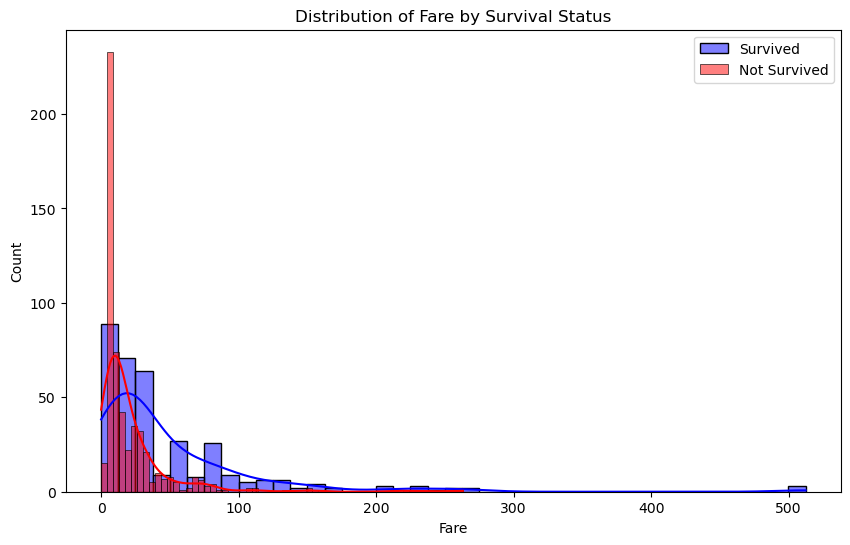

Mean Difference in Fare: 26.27752071709328
Margin of Error: 7.530669209119887
95% Confidence Interval for Mean Difference in Fare: (18.746851507973396, 33.80818992621317)


In [8]:
import numpy as np
from scipy.stats import norm, ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

df = df.dropna(subset=['fare', 'survived'])

fare_survived = df[df['survived'] == 1]['fare']
fare_not_survived = df[df['survived'] == 0]['fare']

t_stat, p_value = ttest_ind(fare_survived, fare_not_survived)
alpha = 0.05  

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Reject the null hypothesis: Fare paid has a significant impact on survival.")
else:
    print("Fail to reject the null hypothesis: Fare paid does not have a significant impact on survival.")

plt.figure(figsize=(10, 6))
sns.histplot(fare_survived, color="blue", kde=True, label="Survived")
sns.histplot(fare_not_survived, color="red", kde=True, label="Not Survived")
plt.legend()
plt.title("Distribution of Fare by Survival Status")
plt.xlabel("Fare")
plt.show()

mean_survived = np.mean(fare_survived)
mean_not_survived = np.mean(fare_not_survived)
std_survived = np.std(fare_survived, ddof=1)
std_not_survived = np.std(fare_not_survived, ddof=1)

n_survived = len(fare_survived)
n_not_survived = len(fare_not_survived)

se_difference = np.sqrt((std_survived ** 2 / n_survived) + (std_not_survived ** 2 / n_not_survived))

confidence_level = 0.95
z_score = norm.ppf((1 + confidence_level) / 2)  

margin_of_error = z_score * se_difference

mean_difference = mean_survived - mean_not_survived
print("Mean Difference in Fare:", mean_difference)
print("Margin of Error:", margin_of_error)
print(f"95% Confidence Interval for Mean Difference in Fare: ({mean_difference - margin_of_error}, {mean_difference + margin_of_error})")
